# Spotify Hit Predictor: EDA & Data Prep

This notebook is the starting point for our IEOR 142 final project. 
The main goal here was to clean the raw Spotify dataset and get it 
into a format we could actually model on.

A few things I ran into that shaped the decisions here:
- The raw data had 114 genres which was way too many, so I grouped 
  them into 10 super-genres
- Same song could appear under multiple genres, so I had to be 
  careful about how I deduplicated
- Defined a "hit" as popularity >= 50 based on the distribution 
  I saw in the data

Output of this notebook: Spotify_Music_Prepared.csv

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import kagglehub # Load data from Kaggle
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (classification_report, confusion_matrix, roc_auc_score, roc_curve, accuracy_score, precision_score, recall_score, f1_score)
from imblearn.over_sampling import SMOTE
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, callbacks
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
import warnings
from statsmodels.stats.outliers_influence import variance_inflation_factor


np.random.seed(42)
pd.set_option('display.max_columns', 50)

## 1. Load the raw data

In [18]:
path = kagglehub.dataset_download("anbudanadithya/spotify-music")
csv_files = [f for f in os.listdir(path) if f.endswith('.csv')]
csv_path = os.path.join(path, csv_files[0])
df = pd.read_csv(csv_path)
df
print(f'Raw shape: {df.shape}')
print(f'Unique genres: {df["track_genre"].nunique()}')
df.head(3)

Using Colab cache for faster access to the 'spotify-music' dataset.
Raw shape: (114000, 21)
Unique genres: 114


,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.461,1,-6.746,0,0.1430,0.0322,0.000001,0.358,0.715,87.917,4,acoustic
1,1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.166,1,-17.235,1,0.0763,0.9240,0.000006,0.101,0.267,77.489,4,acoustic
2,2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.359,0,-9.734,1,0.0557,0.2100,0.000000,0.117,0.120,76.332,4,acoustic


In [19]:
print('Missing values per column:')
print(df.isnull().sum()[df.isnull().sum() > 0])
print(f'\nDuplicate track_ids: {df["track_id"].duplicated().sum()}  (same song, different genre listings)')

Missing values per column:
artists       1
album_name    1
track_name    1
dtype: int64

Duplicate track_ids: 24259  (same song, different genre listings)


## 2. Handle missing values and duplicates

- Drop rows with any null (there's only 1 — an empty artist/album/name combo).
- **Do NOT full-row dedupe.** The dataset lists the same `track_id` under multiple genres on purpose. Instead we keep all (track_id, genre) entries until after we've built grouped-genre flags, then dedupe per track.

In [20]:
df = df.dropna().reset_index(drop=True)
print(f'After dropping nulls: {df.shape}')

After dropping nulls: (113999, 21)


## 3. Drop identifier / high-cardinality text columns

These columns either uniquely identify rows (`track_id`) or would leak signal that has nothing to do with *audio features* (artist, album, track name). The goal is to learn what makes a song popular from its **audio characteristics**, not from memorizing which artists are already famous.

In [21]:
# Keep track_id temporarily so we can dedupe per song after genre grouping; drop the rest
df = df.drop(columns=['artists', 'album_name', 'track_name'])
df['explicit'] = df['explicit'].astype(int)
df.head(3)

,Unnamed: 0,track_id,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,0,5SuOikwiRyPMVoIQDJUgSV,73,230666,0,0.676,0.461,1,-6.746,0,0.1430,0.0322,0.000001,0.358,0.715,87.917,4,acoustic
1,1,4qPNDBW1i3p13qLCt0Ki3A,55,149610,0,0.420,0.166,1,-17.235,1,0.0763,0.9240,0.000006,0.101,0.267,77.489,4,acoustic
2,2,1iJBSr7s7jYXzM8EGcbK5b,57,210826,0,0.438,0.359,0,-9.734,1,0.0557,0.2100,0.000000,0.117,0.120,76.332,4,acoustic


## 4. Group the 114 genres into 10 super-genres

114 one-hot columns would blow up the feature space, create severe multicollinearity, and make feature importance nearly unreadable ("genre_j-idol" is not a useful finding). Grouping by musical family gives interpretable flags a team can actually act on.

Each track gets a 1 in exactly one group (its assigned genre's family). If a genre doesn't match any group, we flag it with a separate `Other` bucket so nothing is silently dropped.

In [ ]:
genre_groups = {
    'Rock_Alternative': ['alt-rock', 'alternative', 'indie', 'indie-pop', 'grunge', 'psych-rock', 'rock', 'rock-n-roll', 'rockabilly', 'punk', 'punk-rock', 
                         'emo', 'goth', 'hardcore'],
    'Electronic_Dance': ['electronic', 'edm', 'electro', 'house', 'techno', 'trance', 'breakbeat', 'drum-and-bass', 'dubstep', 'idm', 'minimal-techno', 
                         'progressive-house', 'chicago-house', 'detroit-techno','club', 'deep-house', 'hardstyle', 'j-dance', 'dance', 'garage', 'disco'],
    'Pop': ['pop', 'synth-pop', 'power-pop', 'pop-film', 'k-pop', 'j-pop', 'cantopop', 'mandopop', 'j-idol', 'anime', 'j-rock'],
    'RnB_Soul': ['hip-hop', 'r-n-b', 'soul', 'funk', 'groove', 'trip-hop'],
    'Metal_HardRock': ['heavy-metal', 'metal', 'black-metal', 'death-metal', 'metalcore', 'grindcore', 'hard-rock', 'industrial'],
    'Latin_Brazilian': ['latin', 'latino', 'salsa', 'tango', 'spanish', 'brazil', 'samba', 'mpb', 'forro', 'pagode', 'sertanejo', 'reggaeton'],
    'Folk_Country_Blues': ['country', 'honky-tonk', 'bluegrass', 'folk', 'blues', 'acoustic', 'guitar', 'singer-songwriter', 'songwriter', 'gospel'],
    'Art_Instrumental': ['jazz', 'classical', 'opera', 'piano'],
    'World': ['reggae', 'ska', 'dancehall', 'dub', 'afrobeat', 'world-music', 'indian', 'malay', 'iranian', 'turkish', 'french', 'german', 'swedish', 'british'],
    'Mood_Ambient': ['ambient', 'chill', 'sleep', 'study', 'new-age', 'kids', 'children', 'disney', 'comedy', 'show-tunes', 'romance', 'sad', 'happy', 'party']
}

# Reverse-lookup: individual genre -> super-genre
genre_to_group = {g: group for group, genres in genre_groups.items() for g in genres}

# Verify every genre in the dataset is mapped
raw_genres = set(df['track_genre'].unique())
mapped = set(genre_to_group.keys()) & raw_genres
unmapped = raw_genres - set(genre_to_group.keys())
print(f'Mapped genres: {len(mapped)} / {len(raw_genres)}')
if unmapped:
    print(f'Unmapped (will go to "Other"): {sorted(unmapped)}')

Mapped genres: 114 / 114


In [23]:
# Assign each track its super-genre, defaulting to 'Other' if its genre isn't in any group
df['genre_group'] = df['track_genre'].map(genre_to_group).fillna('Other')

# Distribution of super-genres
print(df['genre_group'].value_counts())

genre_group
Electronic_Dance      21000
World                 14000
Mood_Ambient          14000
Rock_Alternative      14000
Latin_Brazilian       12000
Pop                   10999
Folk_Country_Blues    10000
Metal_HardRock         8000
RnB_Soul               6000
Art_Instrumental       4000
Name: count, dtype: int64


### Dedupe per track

Now that each track has a super-genre, we collapse duplicate `track_id`s. For tracks that appear under multiple genres, we keep the first occurrence and build a **list of all super-genres** each track belongs to, then create one multi-label flag column per super-genre. This preserves the cross-genre signal (e.g. a song that is both Pop and Electronic_Dance gets a 1 in both) without row duplication.

In [24]:
# For each track_id, collect the set of super-genres it belongs to
track_groups = df.groupby('track_id')['genre_group'].agg(lambda x: set(x))

# Keep one row per track (audio features are identical across genre listings of the same track)
df_unique = df.drop_duplicates(subset='track_id', keep='first').copy()
df_unique['genre_set'] = df_unique['track_id'].map(track_groups)

# Build one flag column per super-genre
all_groups = sorted(set(genre_groups.keys()) | {'Other'})
for g in all_groups:
    df_unique[f'genre_{g}'] = df_unique['genre_set'].apply(lambda s: int(g in s))

# Drop the temporary columns
df_unique = df_unique.drop(columns=['track_id', 'track_genre', 'genre_group', 'genre_set', 'Unnamed: 0'])

print(f'Shape after per-track dedup: {df_unique.shape}')
df_unique.head(3)

Shape after per-track dedup: (89740, 26)


,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,genre_Art_Instrumental,genre_Electronic_Dance,genre_Folk_Country_Blues,genre_Latin_Brazilian,genre_Metal_HardRock,genre_Mood_Ambient,genre_Other,genre_Pop,genre_RnB_Soul,genre_Rock_Alternative,genre_World
0,73,230666,0,0.676,0.461,1,-6.746,0,0.1430,0.0322,0.000001,0.358,0.715,87.917,4,0,0,1,0,0,0,0,1,0,0,0
1,55,149610,0,0.420,0.166,1,-17.235,1,0.0763,0.9240,0.000006,0.101,0.267,77.489,4,0,0,1,0,0,1,0,0,0,0,0
2,57,210826,0,0.438,0.359,0,-9.734,1,0.0557,0.2100,0.000000,0.117,0.120,76.332,4,0,0,1,0,0,0,0,0,0,0,0


## 5. Add the `is_hit` target for classification

In [25]:
df_unique['is_hit'] = (df_unique['popularity'] >= 50).astype(int)
print('Hit vs. non-hit distribution:')
print(df_unique['is_hit'].value_counts(normalize=True).round(3))

Hit vs. non-hit distribution:
is_hit
0    0.764
1    0.236
Name: proportion, dtype: float64


## 6. Sample 50k rows, stratified by `is_hit`

Per the instructor's note. Stratified sampling keeps the same hit/non-hit ratio as the full dataset so the 50k subset is representative.

In [26]:
from sklearn.model_selection import train_test_split

if len(df_unique) > 50_000:
    df_sample, _ = train_test_split(
        df_unique,
        train_size=50_000,
        stratify=df_unique['is_hit'],
        random_state=42,
    )
    df_sample = df_sample.reset_index(drop=True)
else:
    df_sample = df_unique.reset_index(drop=True)

print(f'Sampled shape: {df_sample.shape}')
print(f'Hit ratio in sample: {df_sample["is_hit"].mean():.3f}')

Sampled shape: (50000, 27)
Hit ratio in sample: 0.236


## 7. Sanity checks

In [27]:
print('Final columns:')
print(df_sample.columns.tolist())
print(f'\nFinal shape: {df_sample.shape}')
print(f'Any nulls? {df_sample.isnull().sum().sum()}')
print(f'Dtypes unique: {df_sample.dtypes.unique()}')

Final columns:
['popularity', 'duration_ms', 'explicit', 'danceability', 'energy', 'key', 'loudness', 'mode', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo', 'time_signature', 'genre_Art_Instrumental', 'genre_Electronic_Dance', 'genre_Folk_Country_Blues', 'genre_Latin_Brazilian', 'genre_Metal_HardRock', 'genre_Mood_Ambient', 'genre_Other', 'genre_Pop', 'genre_RnB_Soul', 'genre_Rock_Alternative', 'genre_World', 'is_hit']

Final shape: (50000, 27)
Any nulls? 0
Dtypes unique: [dtype('int64') dtype('float64')]


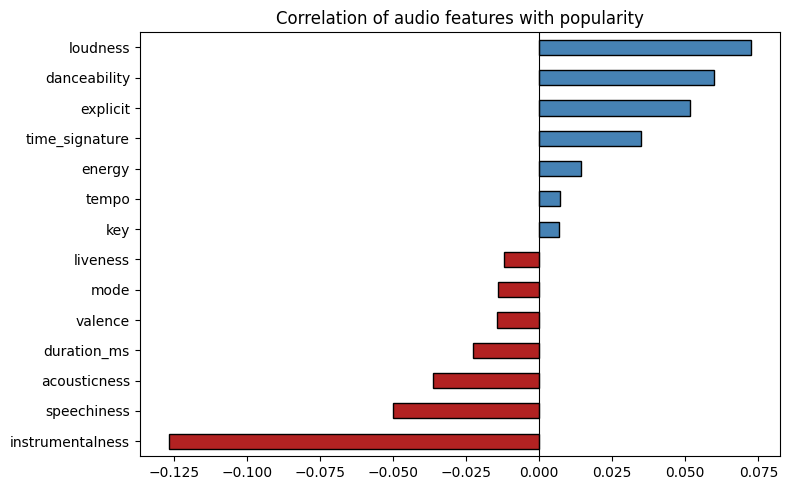

,popularity
instrumentalness,-0.126638
speechiness,-0.049997
acousticness,-0.036346
duration_ms,-0.022751
valence,-0.014454
mode,-0.014026
liveness,-0.011898
key,0.006660
tempo,0.007146
energy,0.014319


In [ ]:
# Correlation of audio features with popularity
audio_cols = ['duration_ms', 'explicit', 'danceability', 'energy', 'key', 'loudness', 'mode',
              'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo','time_signature']

corrs = df_sample[audio_cols + ['popularity']].corr()['popularity'].drop('popularity').sort_values()

plt.figure(figsize=(8, 5))
colors = ['firebrick' if v < 0 else 'steelblue' for v in corrs]
corrs.plot(kind='barh', color=colors, edgecolor='black')
plt.title('Correlation of audio features with popularity')
plt.axvline(0, color='black', linewidth=0.8)
plt.tight_layout()
plt.show()

corrs

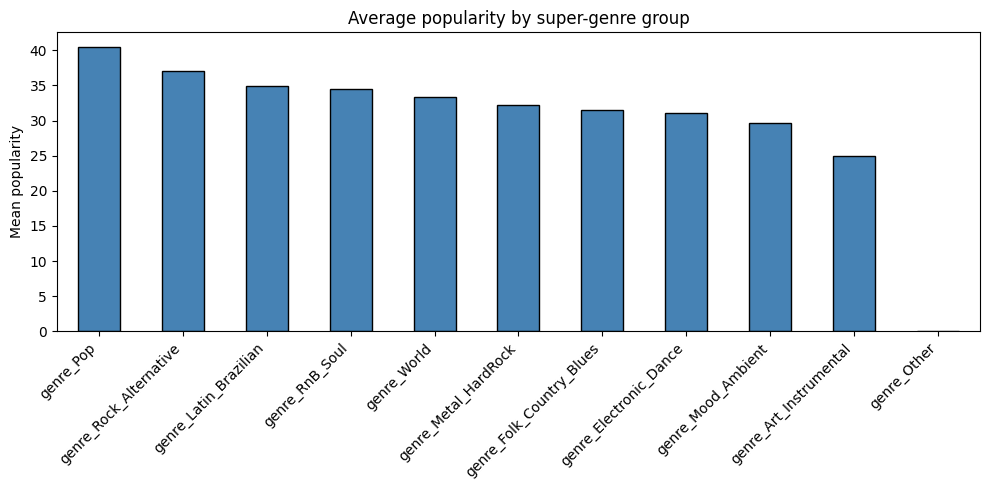

,0
genre_Pop,40.524211
genre_Rock_Alternative,36.984603
genre_Latin_Brazilian,34.865775
genre_RnB_Soul,34.475285
genre_World,33.366525
genre_Metal_HardRock,32.146690
genre_Folk_Country_Blues,31.523372
genre_Electronic_Dance,31.038244
genre_Mood_Ambient,29.698035
genre_Art_Instrumental,24.927340


In [29]:
# Average popularity per super-genre group
genre_flag_cols = [c for c in df_sample.columns if c.startswith('genre_')]
genre_pop = {g: df_sample.loc[df_sample[g] == 1, 'popularity'].mean() for g in genre_flag_cols}
genre_pop_series = pd.Series(genre_pop).sort_values(ascending=False)

plt.figure(figsize=(10, 5))
genre_pop_series.plot(kind='bar', color='steelblue', edgecolor='black')
plt.title('Average popularity by super-genre group')
plt.ylabel('Mean popularity')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

genre_pop_series

In [30]:
df_sample.head(5)

,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,genre_Art_Instrumental,genre_Electronic_Dance,genre_Folk_Country_Blues,genre_Latin_Brazilian,genre_Metal_HardRock,genre_Mood_Ambient,genre_Other,genre_Pop,genre_RnB_Soul,genre_Rock_Alternative,genre_World,is_hit
0,44,203529,0,0.740,0.661,11,-6.823,1,0.2610,0.2880,0.000000,0.1940,0.541,102.052,4,0,1,0,0,0,0,0,0,0,0,0,0
1,49,169508,0,0.670,0.685,1,-9.029,0,0.0631,0.2780,0.000004,0.1030,0.689,159.942,4,0,1,0,0,0,0,0,0,0,1,1,0
2,22,171000,0,0.871,0.505,1,-9.997,1,0.3770,0.0326,0.000001,0.1180,0.383,159.986,4,0,0,0,0,0,1,0,0,0,0,0,0
3,53,201992,0,0.522,0.753,6,-9.301,1,0.0359,0.6540,0.957000,0.2700,0.526,117.128,4,0,1,0,0,0,0,0,0,0,0,0,1
4,53,114857,0,0.849,0.878,10,-0.072,0,0.3300,0.0799,0.567000,0.0302,0.564,139.879,4,0,1,0,0,0,0,0,0,0,0,1,1


## 8. Save the prepared dataset

In [31]:
df_sample.to_csv('Spotify_Music_prepared.csv', index=False)
print(f'Saved: Spotify_Music_prepared.csv ({df_sample.shape[0]:,} rows × {df_sample.shape[1]} columns)')

Saved: Spotify_Music_prepared.csv (50,000 rows × 27 columns)
